# گزارش نهایی پروژه پیش‌بینی حقوق
**مدل:** رگرسیون خطی (مناسب برای دیتاست کوچک)

**هدف:** پیش‌بینی لگاریتم حقوق بر اساس ویژگی‌های شغلی

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.metrics import r2_score, mean_squared_error
from pathlib import Path

In [2]:
root = Path.cwd().parent  
artifact_dir = root / "data" / "artifact"

model = joblib.load(artifact_dir / "lr.joblib")
feature_columns = joblib.load(artifact_dir / "lr_columns.joblib")

print("Model and columns loaded successfully.")
print(f" number of features: {len(feature_columns)}")

Model and columns loaded successfully.
 number of features: 17


In [3]:
db_path = root / "data" / "db" / "salary_data.db"
engine = create_engine(f"sqlite:///{db_path}")
df = pd.read_sql("SELECT * FROM final_data", engine)
print(f" number of rows: {len(df)}")
df.head()

 number of rows: 607


,Unnamed: 0,experience_rank,company_size_M,company_size_S,employment_type_FL,employment_type_FT,employment_type_PT,remote_ratio_50,remote_ratio_100,job_group_Data Engineer,job_group_Data Scientist,job_group_Machine Learning Engineer,job_group_Other,job_group_Research Scientist,location_group_DE,location_group_GB,location_group_Other,location_group_US,log_salary
0,0,2,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,11.287705
1,1,3,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,12.468441
2,2,3,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,11.599332
3,3,2,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,9.903538
4,4,3,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,11.918397


In [4]:
exclude = ["log_salary", "Unnamed: 0"]
existing_exclude = [c for c in exclude if c in df.columns]
X = df.drop(columns=existing_exclude)
Y_log = df["log_salary"]

X = X[feature_columns] 

y_pred_log = model.predict(X)
y_real_usd = np.expm1(Y_log)
y_pred_usd = np.expm1(y_pred_log)

In [5]:
r2 = r2_score(Y_log, y_pred_log)
rmse_usd = np.sqrt(mean_squared_error(y_real_usd, y_pred_usd))
mae_usd = np.mean(np.abs(y_real_usd - y_pred_usd))

print("="*40)
print("عملکرد مدل رگرسیون خطی")
print("="*40)
print(f"R² (ضریب تعیین): {r2:.4f}")
print(f"RMSE (دلار): ${rmse_usd:,.0f}")
print(f"MAE  (دلار): ${mae_usd:,.0f}")
print("="*40)

عملکرد مدل رگرسیون خطی
R² (ضریب تعیین): 0.5689
RMSE (دلار): $50,989
MAE  (دلار): $32,092


In [6]:
coefficients = model.coef_
coef_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": coefficients
}).sort_values("coefficient", key=abs, ascending=False)

print("10 ویژگی با بیشترین تأثیر (قدر مطلق ضریب):")
print(coef_df.head(10).to_string(index=False))

print("\نکته: ضریب مثبت یعنی افزایش آن ویژگی، حقوق را افزایش می‌دهد.")

10 ویژگی با بیشترین تأثیر (قدر مطلق ضریب):
                            feature  coefficient
                 employment_type_FL    -1.224763
                 employment_type_PT    -0.905400
               location_group_Other    -0.671676
       job_group_Research Scientist     0.598705
job_group_Machine Learning Engineer     0.466356
                  location_group_US     0.342878
                    job_group_Other     0.337248
                    experience_rank     0.313590
           job_group_Data Scientist     0.271685
            job_group_Data Engineer     0.248658
\نکته: ضریب مثبت یعنی افزایش آن ویژگی، حقوق را افزایش می‌دهد.


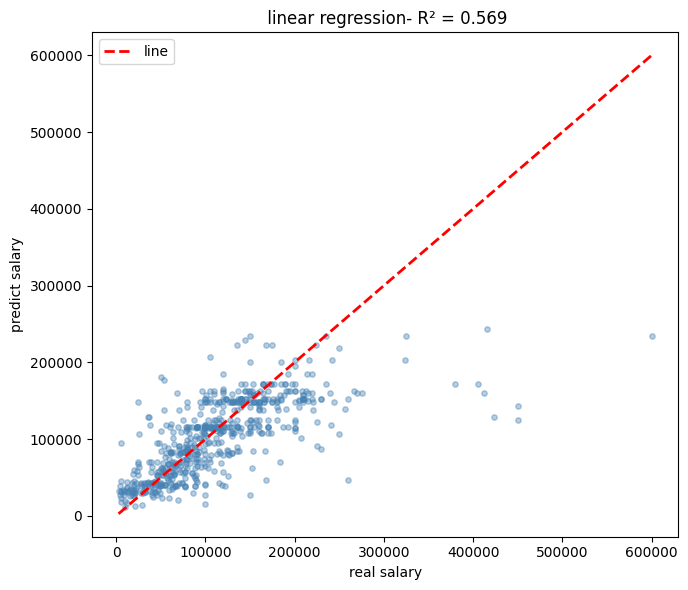

In [7]:
plt.figure(figsize=(7,6))
plt.scatter(y_real_usd, y_pred_usd, alpha=0.4, s=15, c='steelblue')
plt.plot([y_real_usd.min(), y_real_usd.max()], 
         [y_real_usd.min(), y_real_usd.max()], 'r--', lw=2, label="line")
plt.xlabel("real salary")
plt.ylabel("predict salary")
plt.title(f" linear regression- R² = {r2:.3f}")
plt.legend()
plt.tight_layout()
#plt.savefig("real_vs_pred.png", dpi=120)
plt.show()
#print("  saved chart: real_vs_pred.png")

In [8]:
#sample_df = X.iloc[:5].copy()
#sample_pred_log = model.predict(sample_df)
#sample_pred_usd = np.expm1(sample_pred_log)
#sample_real_usd = y_real_usd.iloc[:5]

#comparison = pd.DataFrame({
#    "real salaries": sample_real_usd,
#    "predict salaries": sample_pred_usd,
#    "error(usd)": sample_real_usd - sample_pred_usd
#})
#print(" sample of predicts :")
#print(comparison.round(0).to_string())

##  نتیجه‌گیری    

- داده‌ها پس از پاکسازی و مهندسی ویژگی با موفقیت آماده شدند.
- به دلیل حجم کم داده‌ها، مدل **رگرسیون خطی** عملکرد بهتری نسبت به مدل‌های پیچیده‌تر داشت.
- میزان **R² = 0.5689** نشان می‌دهد که مدل قادر است حدود 60% از تغییرات حقوق را توضیح دهد.
- **RMSE حدود $50,989 دلار** – با توجه به میانگین حقوق و واقعی بودن و محدود بودن داده ها ، خطای قابل قبولی است.
- مهم‌ترین ویژگی‌های مؤثر: (از جدول ضرایب، ۳ مورد اول را نام ببر).
- کد پروژه کاملاً ماژولار (DataPreparator, ModelTrainer) و قابل بازتولید است.
- در نسخه بعدی یک endpoint با fast api برای استفاده از مدل ساخته میشود و میتوانیم به فرانت اند دولوپر ها اراعه کنیم